# Waterfilling Levels

In [1]:
import sys
sys.path.insert(1, '../../functions')
import importlib
import numpy as np
import nbformat
import plotly.express
import plotly.express as px
import pandas as pd
import scipy.optimize as optimization
import food_bank_functions
import food_bank_bayesian
import matplotlib.pyplot as plt
import seaborn as sns
from food_bank_functions import *
from food_bank_bayesian import *
importlib.reload(food_bank_functions)

<module 'food_bank_functions' from '../../functions\\food_bank_functions.py'>

### Plotting the distribution

In [2]:
vals = np.loadtxt('../../data/gaussian/vals_15_var_3.csv', delimiter=",")
support = np.loadtxt('../../data/gaussian/support_15_var_3.csv', delimiter=",")
var = variance(support, vals)
med = median(support, vals)
print(med)
print(var)

15.5
9.603062592934334


In [3]:
print(vals)
print(support)
vals[0] = vals[0] + (1 - np.sum(vals))

[0.0000e+00 3.3000e-04 5.3400e-03 4.5740e-02 1.8204e-01 3.3487e-01
 2.8992e-01 1.1717e-01 2.2520e-02 2.0000e-03 7.0000e-05]
[ 2.          4.7         7.4        10.1        12.8        15.5
 18.2        20.9        23.6        26.3        27.20911003]


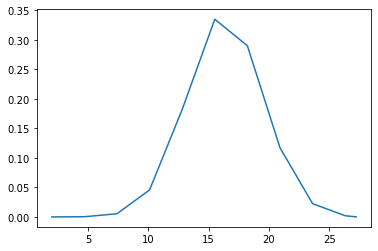

In [4]:
plt.plot(support, vals)

### Test

In [5]:
n = 6
sorted_distribution = support
weights = vals
expected_demand = np.dot(vals, support)
print(expected_demand)
max_budget = n * expected_demand

16.33501163770181


In [6]:
print(max_budget)

98.01006982621087


In [7]:
np.sum(vals)

1.0

In [8]:
group_demands = np.random.choice(size=n, a=sorted_distribution, p=vals)
print(group_demands)

[15.5 12.8 15.5 12.8 20.9 18.2]


In [9]:
print(waterfilling_waste(group_demands, max_budget))

[15.5 12.8 15.5 12.8 20.9 18.2]


In [10]:
print(greedy(group_demands, max_budget))

[15.5 12.8 15.5 12.8 20.9 18.2]


In [11]:
print(constant_threshold(group_demands,max_budget,expected_demand))

[15.5        12.8        15.5        12.8        16.33501164 16.33501164]


In [12]:
print(waterfilling_proportional_remaining(group_demands, max_budget))

[15.5        12.8        15.5        12.8        20.70503491 18.2       ]


In [13]:
print(waterfilling_dynamic_waste([expected_demand for x in range(n)],group_demands,max_budget))

[15.5 12.8 15.5 12.8 20.9 18.2]


In [14]:
print(waterfilling_dynamic_full_waste([expected_demand for x in range(n)],group_demands,max_budget))

[15.5 12.8 15.5 12.8 20.9 18.2]


In [15]:
print(waterfilling_weights_waste_iid(weights, sorted_distribution, group_demands, max_budget))

[15.5 12.8 15.5 12.8 20.9 18.2]


In [16]:
print(weights)
print(sorted_distribution)

[1.11022302e-16 3.30000000e-04 5.34000000e-03 4.57400000e-02
 1.82040000e-01 3.34870000e-01 2.89920000e-01 1.17170000e-01
 2.25200000e-02 2.00000000e-03 7.00000000e-05]
[ 2.          4.7         7.4        10.1        12.8        15.5
 18.2        20.9        23.6        26.3        27.20911003]


In [17]:
print(waterfilling_weights_full_waste_iid(weights, sorted_distribution, group_demands, max_budget))

[15.5 12.8 15.5 12.8 20.9 18.2]


In [18]:
print(max_min_heuristic(group_demands, [med for x in range(n)], [expected_demand for x in range(n)], [var for x in range(n)], max_budget))

[15.5 12.8 15.5 12.8 20.9 18.2]


# Experiments

## Varying Number of Groups

### Look at scaling with n

In [19]:
max_n = 100
num_iterations = 100
print(weights)
print(sorted_distribution)

[1.11022302e-16 3.30000000e-04 5.34000000e-03 4.57400000e-02
 1.82040000e-01 3.34870000e-01 2.89920000e-01 1.17170000e-01
 2.25200000e-02 2.00000000e-03 7.00000000e-05]
[ 2.          4.7         7.4        10.1        12.8        15.5
 18.2        20.9        23.6        26.3        27.20911003]


In [20]:
expected_waterfilling_threshold = np.zeros(max_n+1)
num_iterations = 1000
for i in np.arange(2,max_n+1):
    for _ in range(num_iterations):
        budget = i * 15.
        demands = np.random.choice(size=i, a=support, p=vals)
        opt = waterfilling_waste(demands, budget)
        expected_waterfilling_threshold[i] += (1/num_iterations)*max(opt)
print(expected_waterfilling_threshold)

[ 0.          0.         15.3878     15.90315    16.16213333 16.29608333
 16.4624     16.42282833 16.43753571 16.39323679 16.45487385 16.43259385
 16.48979866 16.43749063 16.445509   16.49398438 16.47339581 16.41054891
 16.39631425 16.30621628 16.35136562 16.38302119 16.37317259 16.42189666
 16.38470819 16.37286022 16.34349691 16.34484754 16.34383735 16.30999785
 16.30968154 16.27377968 16.31666094 16.29557454 16.23969086 16.31442622
 16.29602261 16.33023427 16.25001    16.30198533 16.27048527 16.22209618
 16.28773551 16.23228742 16.2283106  16.26307826 16.20411937 16.222834
 16.21436219 16.23770318 16.26530036 16.23980087 16.24896323 16.21910828
 16.27985937 16.21012629 16.23836224 16.21490813 16.2352468  16.25649499
 16.24506035 16.19953345 16.20843882 16.20988676 16.20932216 16.18499134
 16.19651133 16.2105643  16.22709652 16.19889907 16.20087311 16.18572052
 16.20414099 16.20512907 16.19985253 16.20671017 16.21657791 16.20583994
 16.20283643 16.18200167 16.20860198 16.22269906 16.2

In [59]:
data_dict = {'NumGroups':[], 'Norm':[], 'ET-Online':[],'Hope-Online':[], 'Adapt-Threshold':[], 'Threshold':[], 'Expected-Filling':[], 'Greedy':[], 'ET-Full':[], 'Hope-Full':[], 'Max-Min':[]}
num_iterations = 200
for n in np.arange(2,max_n+1,1):
    n = max(int(n),1)
    group_expected_demands = np.zeros(n) + np.dot(weights, sorted_distribution)
    group_median_demands = np.zeros(n) + med
    group_variance = np.zeros(n) + var
    budget = n*expected_demand
    print(n)
    for i in range(num_iterations):
        data_dict['NumGroups'].append(n)

        
        group_demands = np.random.choice(size=n, a=support, p=vals)
        opt = waterfilling_waste(group_demands,budget)
        
        weights_sol = waterfilling_weights_waste_iid(weights, sorted_distribution, group_demands, budget)
        weights_full_sol = waterfilling_weights_full_waste_iid(weights, sorted_distribution, group_demands, budget)
        dynamic = waterfilling_dynamic_waste(group_expected_demands,group_demands,budget)
        dynamic_full = waterfilling_dynamic_full_waste(group_expected_demands, group_demands, budget)
        proportional_threshold = waterfilling_proportional_remaining(group_demands, budget)
        greed_sol = greedy(group_demands,budget)
        threshold = constant_threshold(group_demands,budget,expected_demand)
        expect_threshold = constant_threshold(group_demands, budget, expected_waterfilling_threshold[n])
        max_min_heuristic_sol = max_min_heuristic(group_demands, group_median_demands, group_expected_demands, group_variance, budget)
        
        data_dict['Norm'].append('L1')
        data_dict['Hope-Online'].append(np.sum(np.absolute(opt - weights_sol)))
        data_dict['ET-Online'].append(np.sum(np.absolute(opt-dynamic)))
        data_dict['Adapt-Threshold'].append(np.sum(np.absolute(opt - proportional_threshold)))
        data_dict['Greedy'].append(np.sum(np.absolute(opt-greed_sol)))
        data_dict['Threshold'].append(np.sum(np.absolute(opt-threshold)))
        data_dict['ET-Full'].append(np.sum(np.absolute(opt-dynamic_full)))
        data_dict['Hope-Full'].append(np.sum(np.absolute(opt-weights_full_sol)))
        data_dict['Expected-Filling'].append(np.sum(np.absolute(opt - expect_threshold)))
        data_dict['Max-Min'].append(np.sum(np.absolute(opt - max_min_heuristic_sol)))
        
        data_dict['NumGroups'].append(n)
        data_dict['Norm'].append('Linf')
        data_dict['Hope-Online'].append(np.max(np.absolute(opt - weights_sol)))
        data_dict['ET-Online'].append(np.max(np.absolute(opt-dynamic)))
        data_dict['Adapt-Threshold'].append(np.max(np.absolute(opt - proportional_threshold)))
        data_dict['Greedy'].append(np.max(np.absolute(opt-greed_sol)))
        data_dict['Threshold'].append(np.max(np.absolute(opt-threshold)))
        data_dict['ET-Full'].append(np.max(np.absolute(opt-dynamic_full)))
        data_dict['Hope-Full'].append(np.max(np.absolute(opt-weights_full_sol)))
        data_dict['Expected-Filling'].append(np.max(np.absolute(opt - expect_threshold)))
        data_dict['Max-Min'].append(np.max(np.absolute(opt - max_min_heuristic_sol)))

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


In [60]:
df = pd.DataFrame(data_dict).melt(id_vars=["NumGroups", 'Norm'])

In [61]:
algos_to_exclude = ['Threshold','Expected-Filling']
data_to_graph = (df[~df.variable.isin(algos_to_exclude)]
                 .rename({'variable': 'Algorithm'}, axis = 1)
                )

In [62]:
plt.style.use('PaperDoubleFig.mplstyle.txt')
# Make some style choices for plotting 
colorWheel =['#2bd1e5',
            '#281bf5',
             '#db1bf5',
             '#F5CD1B',
            '#FF5733','#9cf51b',]
dashesStyles = [[3,1],
            [2,1,10,1],
            [4, 1, 1, 1, 1, 1],[1000,1],[8,2]]

In [63]:
data_to_graph = data_to_graph.sort_values(by='Algorithm')

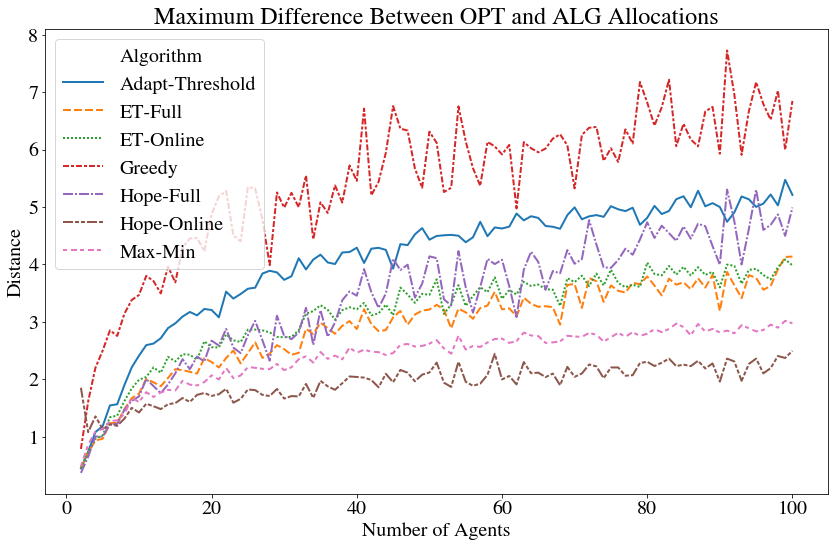

In [64]:
filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
plt.figure(figsize=(12,8))
plt.title('Gaussian L1')
dash_styles = ["",
               (4, 1.5),
               (1, 1),
               (3, 1, 1.5, 1),
               (5, 1, 1, 1),
               (5, 1, 2, 1, 2, 1),
               (2, 2, 3, 1.5),
               (1, 2.5, 3, 1.2)]

sns.lineplot(x='NumGroups', y='value', hue='Algorithm', style = 'Algorithm', dashes = dash_styles, data=data_to_graph[data_to_graph.Norm == 'Linf'], ci = None)
plt.xlabel('Number of Agents')
plt.ylabel('Distance')
plt.title('Maximum Difference Between OPT and ALG Allocations')
plt.savefig('linf.pdf')

In [27]:
data_to_graph.Algorithm.unique()

array(['Adapt-Threshold', 'ET-Full', 'ET-Online', 'Greedy', 'Hope-Full',
       'Hope-Online', 'Max-Min'], dtype=object)

In [28]:
data_to_graph.head

<bound method NDFrame.head of         NumGroups  Norm        Algorithm      value
79201           2  Linf  Adapt-Threshold   0.000000
92405          35  Linf  Adapt-Threshold   3.561330
92404          35    L1  Adapt-Threshold  20.229795
92403          35  Linf  Adapt-Threshold   2.316114
92402          35    L1  Adapt-Threshold  20.828531
...           ...   ...              ...        ...
330001         35  Linf          Max-Min   2.013116
330002         35    L1          Max-Min  58.918673
330003         35  Linf          Max-Min   2.815106
329996         34    L1          Max-Min  52.414371
356399        100  Linf          Max-Min   2.877344

[277200 rows x 4 columns]>

In [29]:
df.to_csv('scale_with_n.csv')

In [30]:
df.columns

Index(['NumGroups', 'Norm', 'variable', 'value'], dtype='object')

In [31]:
df.head

<bound method NDFrame.head of         NumGroups  Norm   variable       value
0               2    L1  ET-Online    0.000000
1               2  Linf  ET-Online    0.000000
2               2    L1  ET-Online    0.000000
3               2  Linf  ET-Online    0.000000
4               2    L1  ET-Online    0.000000
...           ...   ...        ...         ...
356395        100  Linf    Max-Min    2.942824
356396        100    L1    Max-Min  161.239389
356397        100  Linf    Max-Min    2.162809
356398        100    L1    Max-Min  213.317719
356399        100  Linf    Max-Min    2.877344

[356400 rows x 4 columns]>

In [32]:
df[df.variable == 'Weights'].head

<bound method NDFrame.head of Empty DataFrame
Columns: [NumGroups, Norm, variable, value]
Index: []>

<AxesSubplot:title={'center':'Gaussian L1'}, xlabel='NumGroups', ylabel='value'>

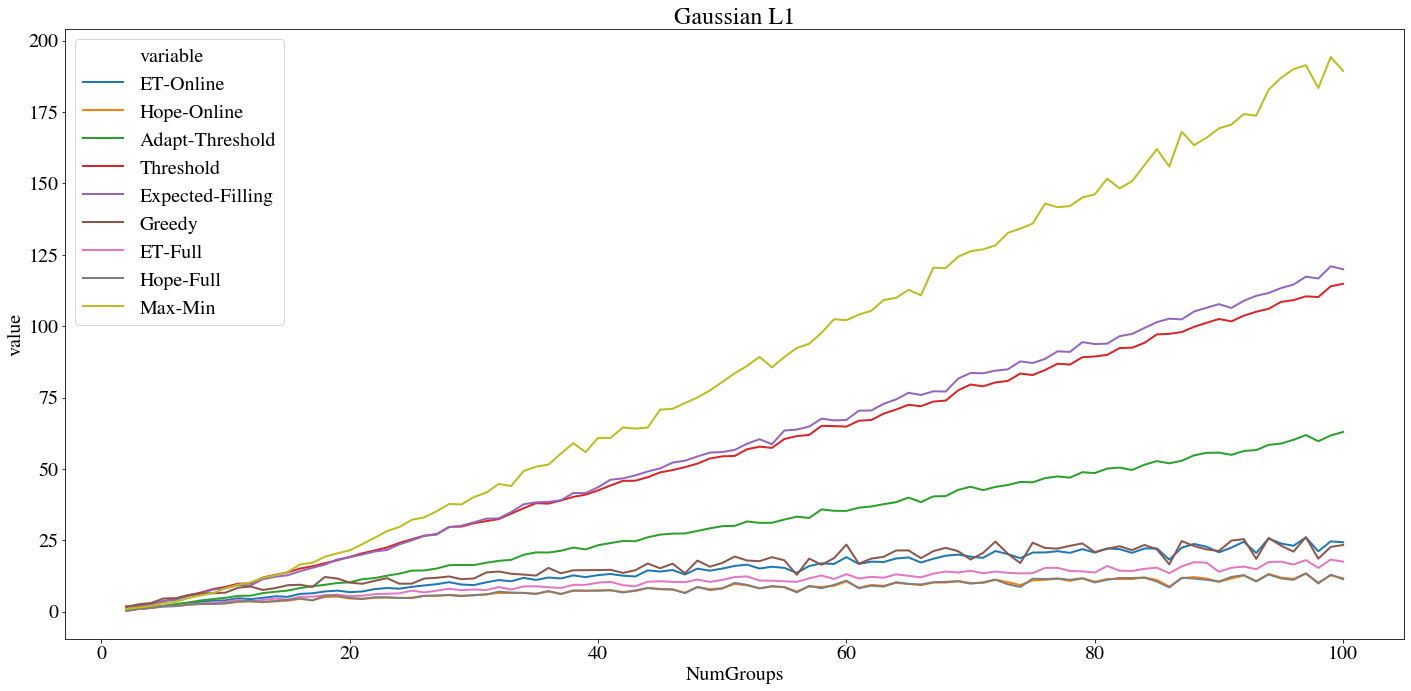

In [33]:
filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
plt.figure(figsize=(20,10))
plt.title('Gaussian L1')
sns.lineplot(x='NumGroups', y='value', hue='variable', data=df[df.Norm == 'L1'], ci = None)

In [34]:
filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
df = df[df.]
plt.figure(figsize=(20,10))
plt.title('Gaussian Linf')
sns.lineplot(x='NumGroups', y='value', hue='variable', data=df[df.Norm == 'Linf'])

SyntaxError: invalid syntax (<ipython-input-34-e88e3079bbc9>, line 2)

In [ ]:
data_dict = {'Group':[], 'Weights_Full':[], 'Weights_Online':[],'Dynamic_Full':[], 'Dynamic_Online':[], 'True':[], 'Max_Min_Heuristic':[]}
num_iterations = 100


for i in range(num_iterations):
    max_n = 100
    
    weights = np.loadtxt('../../data/gaussian/vals_15_var_3.csv', delimiter=",")
    sorted_support = np.loadtxt('../../data/gaussian/support_15_var_3.csv', delimiter=",")
    
    expected_demands = [expected_demand for x in range(max_n)]
    median_demands = [med for _ in range(max_n)]
    variance = [var for _ in range(max_n)]
    
    # print(weights)
    # print(sorted_support)
    # print(expected_demands)
    max_budget = max_n*expected_demand
    
    
    
    group_demands = np.random.choice(size=max_n, a=sorted_support, p=weights).astype(np.float)
    print('Demands for experiment:' + str(group_demands))   
    
    dynamic_full = np.copy(expected_demands)
    dynamic_online = np.sort(np.copy(expected_demands))
    
    dynamic_online_budget = max_budget
    weights_online_budget = max_budget

    weights_online_support = np.copy(sorted_support)
    weights_online_vals = np.copy(weights)*max_n
    
    weights_full_support = np.copy(sorted_support)
    weights_full_vals = np.copy(weights)*max_n
    print('start')
    print(weights_full_vals)
    print(np.sum(weights_full_vals))
    max_min_budget = max_budget
    min_fill = 1
    
    for n in range(max_n):
        # Solve for the various waterfilling levels
        data_dict['Group'].append(n)
        
        # Adds on the true waterfilling level
        data_dict['True'].append(max(waterfilling_sorted(np.sort(np.copy(group_demands)), max_budget)))
        
        
        # Dynamic_Full
        
        # Replaces current town's demand with realized demand
        dynamic_full[n] = group_demands[n]
        # Sorts demands
        dynamic_full_sorted = np.sort(np.copy(dynamic_full))
        # Appends maximum allocation based on full demand with full budget
        data_dict['Dynamic_Full'].append(max(waterfilling_sorted(dynamic_full_sorted, max_budget)))
            
            
        # Dynamic_Online
        
        # Removes expected demand for current agent from list
        dynamic_online = delete_sorted(dynamic_online, expected_demands[n])
        
        # adds in the demand for current location
        new_sorted_list, index = insert_sorted(dynamic_online, group_demands[n])
        tmp_sol = waterfilling_sorted(new_sorted_list, dynamic_online_budget)
        data_dict['Dynamic_Online'].append(max(tmp_sol))
        # subtracts off the allocation for the next round
        dynamic_online_budget -= min(tmp_sol[index], dynamic_online_budget, group_demands[n])
        
        
        # Weights_Full
        
        # Updating the weights for the observed group
        obs_demand = group_demands[n]
        
        index = np.argmin(np.abs(weights_full_support - obs_demand))
        weights_full_vals -= weights
        weights_full_vals[index] += 1
        
        data_dict['Weights_Full'].append(max(waterfilling_sorted_weights(weights_full_support, weights_full_vals, max_budget)))
        
        
#         if n == max_n - 1:
#             print(max(waterfilling_sorted(np.sort(np.copy(group_demands)), max_budget)))
#             print(max(waterfilling_sorted_weights(weights_full_support, weights_full_vals, max_budget)))
#             print(weights_full_vals)
        
        # Weights_Online
        obs_demand = group_demands[n]
        
        index = np.argmin(np.abs(weights_online_support - obs_demand))
        weights_online_vals -= weights
        weights_online_vals[index] += 1        
        
        
        tmp_sol = waterfilling_sorted_weights(weights_online_support, weights_online_vals, weights_online_budget)
        weights_online_budget -= min(obs_demand, weights_online_budget, tmp_sol[index])
        
        weights_online_vals[index] -= 1
        data_dict['Weights_Online'].append(max(tmp_sol))
        
        # Max_Min
        
        if n == max_n - 1:
            data_dict['Max_Min_Heuristic'].append(min(max_min_budget, group_demands[n]))
        else:
            delta = (median_demands[n] - median_demands[n+1]) / ((1/2)* (median_demands[n] + median_demands[n+1]))
            budget_portion = max_min_budget * (expected_demands[n] + expected_demands[n+1]) / np.sum(expected_demands[n:])
            heuristic_threshold = budget_portion * (group_demands[n] / (group_demands[n] + median_demands[n+1] + delta * np.sqrt(variance[n+1])))
            allocation = min(heuristic_threshold, min_fill*group_demands[n], max_min_budget)
            data_dict['Max_Min_Heuristic'].append(heuristic_threshold)
            
            if allocation / group_demands[n] <= min_fill:
                min_fill = allocation / group_demands[n]
            max_min_budget -= allocation


In [ ]:
np.std(data_dict['True'])

In [ ]:
df = pd.DataFrame(data_dict).melt(id_vars="Group")

In [ ]:
df.to_csv('comparison_of_waterfilling_levels.csv')

In [ ]:
plt.figure(figsize=(20,10))
sns.lineplot(x='Group', y='value', style='variable', hue = 'variable', data=df)
plt.title('Estimated Waterfilling Levels')
plt.xlabel('Estimated Level')

### Calculating Fairness Statistics


In [65]:
num_iterations = 1000
weights = np.loadtxt('../../data/gaussian/vals_15_var_3.csv', delimiter=",")
sorted_distribution = np.loadtxt('../../data/gaussian/support_15_var_3.csv', delimiter=",")
expected_demand = np.dot(weights, sorted_distribution)
n=100

In [66]:
group = np.arange(n)
group_expected_demands = np.zeros(n) + expected_demand
budget = expected_demand*n
score_weights_online = np.zeros((n,num_iterations))
score_weights_full = np.zeros((n,num_iterations))
score_dynamic_online = np.zeros((n,num_iterations))
score_dynamic_full = np.zeros((n,num_iterations))
score_greedy = np.zeros((n,num_iterations))
score_adapt_threshold = np.zeros((n,num_iterations))
score_fixed_threshold = np.zeros((n,num_iterations))
score_expect_threshold = np.zeros((n, num_iterations))
score_max_min = np.zeros((n, num_iterations))

# 8 different algorithms
env = np.zeros((9,num_iterations))
po = np.zeros((9,num_iterations))
prop = np.zeros((9,num_iterations))
linf = np.zeros((9,num_iterations))
max_min = np.zeros((9, num_iterations))
for i in range(num_iterations):
    budget = n*np.dot(weights, sorted_distribution)

        
    group_demands = np.random.choice(size=n, a=sorted_distribution, p=weights)
    group_median_demands = np.zeros(n) + med
    group_variance = np.zeros(n) + var
    
    opt = waterfilling_waste(group_demands,budget)

    weights_sol = waterfilling_weights_waste_iid(weights, sorted_distribution, group_demands, budget)
    weights_full_sol = waterfilling_weights_full_waste_iid(weights, sorted_distribution, group_demands, budget)
    dynamic = waterfilling_dynamic_waste(group_expected_demands,group_demands,budget)
    dynamic_full = waterfilling_dynamic_full_waste(group_expected_demands, group_demands, budget)
    proportional_threshold = waterfilling_proportional_remaining(group_demands, budget)
    greedy_sol = greedy(group_demands,budget)
    threshold = constant_threshold(group_demands,budget,expected_demand)
    expect_threshold = constant_threshold(group_demands, budget, expected_waterfilling_threshold[n])
    max_min_heuristic_sol = max_min_heuristic(group_demands, group_median_demands, group_expected_demands, group_variance, budget)

    # comparing weights_online
    
    score_weights_online[:,i] = opt - weights_sol
    env[0,i] = max(0,np.amax(envy_utility(weights_sol,group_demands)))
    po[0,i] = excess(weights_sol,budget)
    prop[0,i] = np.amax(proportionality_utility(weights_sol,group_demands,budget))
    max_min[0,i] = np.min(utility_ratio(weights_sol, group_demands, budget))
    linf[0,i] = np.amax(np.abs(score_weights_online[:,i]))
    
    
    # comparing weights_full
    
    score_weights_full[:,i] = opt - weights_full_sol
    env[1,i] = max(0,np.amax(envy_utility(weights_full_sol,group_demands)))
    po[1,i] = excess(weights_full_sol,budget)
    prop[1,i] = np.amax(proportionality_utility(weights_full_sol,group_demands,budget))
    max_min[1,i] = np.min(utility_ratio(weights_full_sol, group_demands, budget))
    linf[1,i] = np.amax(np.abs(score_weights_full[:,i]))
    
    
    # comparing dynamic_online
    
    score_dynamic_online[:,i] = opt - dynamic
    env[2,i] = max(0,np.amax(envy_utility(dynamic,group_demands)))
    po[2,i] = excess(dynamic,budget)
    prop[2,i] = np.amax(proportionality_utility(dynamic,group_demands,budget))
    max_min[2,i] = np.min(utility_ratio(dynamic, group_demands, budget))
    linf[2,i] = np.amax(np.abs(score_dynamic_online[:,i]))
    
    
    # comparing dynamic_full
    
    score_dynamic_full[:,i] = opt - dynamic_full
    env[3,i] = max(0,np.amax(envy_utility(dynamic_full,group_demands)))
    po[3,i] = excess(dynamic_full,budget)
    prop[3,i] = np.amax(proportionality_utility(dynamic_full,group_demands,budget))
    max_min[3,i] = np.min(utility_ratio(dynamic_full, group_demands, budget))
    linf[3,i] = np.amax(np.abs(score_dynamic_full[:,i]))
    
    
    # comparing greedy
    
    score_greedy[:,i] = opt - greedy_sol
    env[4,i] = max(0,np.amax(envy_utility(greedy_sol,group_demands)))
    po[4,i] = excess(greedy_sol,budget)
    prop[4,i] = np.amax(proportionality_utility(greedy_sol,group_demands,budget))
    max_min[4,i] = np.min(utility_ratio(greedy_sol, group_demands, budget))
    linf[4,i] = np.amax(np.abs(score_greedy[:,i]))
    
    # comparing fixed_threshold
    
    score_fixed_threshold[:,i] = opt - threshold
    env[5,i] = max(0,np.amax(envy_utility(threshold,group_demands)))
    po[5,i] = excess(threshold,budget)
    prop[5,i] = np.amax(proportionality_utility(threshold,group_demands,budget))
    max_min[5,i] = np.min(utility_ratio(threshold, group_demands, budget))
    linf[5,i] = np.amax(np.abs(score_fixed_threshold[:,i]))
    
    
    # comparing adaptive_threshold
    
    score_adapt_threshold[:,i] = opt - proportional_threshold
    env[6,i] = max(0,np.amax(envy_utility(proportional_threshold,group_demands)))
    po[6,i] = excess(proportional_threshold,budget)
    prop[6,i] = np.amax(proportionality_utility(proportional_threshold,group_demands,budget))
    max_min[6,i] = np.min(utility_ratio(proportional_threshold, group_demands, budget))
    linf[6,i] = np.amax(np.abs(score_adapt_threshold[:,i]))    

    # comparing expected_threshold
    
    score_expect_threshold[:,i] = opt - expect_threshold
    env[7,i] = max(0,np.amax(envy_utility(expect_threshold,group_demands)))
    po[7,i] = excess(expect_threshold,budget)
    prop[7,i] = np.amax(proportionality_utility(expect_threshold,group_demands,budget))
    max_min[7,i] = np.min(utility_ratio(expect_threshold, group_demands, budget))
    linf[7,i] = np.amax(np.abs(score_expect_threshold[:,i]))
    

    # comparing max_min_heurstic
    
    score_max_min[:,i] = opt - max_min_heuristic_sol
    env[8,i] = max(0,np.amax(envy_utility(max_min_heuristic_sol,group_demands)))
    po[8,i] = excess(max_min_heuristic_sol,budget)
    prop[8,i] = np.amax(proportionality_utility(max_min_heuristic_sol,group_demands,budget))
    max_min[8,i] = np.min(utility_ratio(max_min_heuristic_sol, group_demands, budget))
    linf[8,i] = np.amax(np.abs(score_max_min[:,i])) 

In [67]:
score_weights_online = np.average(score_weights_online, axis=1)
score_weights_full = np.average(score_weights_full, axis=1)
score_dynamic_online = np.average(score_dynamic_online, axis=1)
score_dynamic_full = np.average(score_dynamic_full, axis=1)
score_greedy = np.average(score_greedy, axis=1)
score_adapt_threshold = np.average(score_adapt_threshold, axis=1)
score_fixed_threshold = np.average(score_fixed_threshold, axis=1)
score_expect_threshold = np.average(score_expect_threshold, axis=1)
score_max_min = np.average(score_max_min, axis=1)

env = np.average(env,axis=1)
po = np.average(po,axis=1)
prop = np.average(prop,axis=1)
linf = np.average(linf,axis=1)
max_min = np.average(max_min, axis=1)

In [68]:
print(env)

[0.1150385  0.26465955 0.20148213 0.20138174 0.39630431 0.
 0.21946642 0.         0.13394336]


In [69]:
print(po)

[0.15744465 0.1442845  0.23191124 0.24542171 0.12522712 1.25716632
 0.7048466  1.30780269 2.02248797]


In [70]:
print(prop)

[1.22869240e-02 2.13196862e-01 6.69797551e-16 6.62419392e-02
 3.71032599e-01 0.00000000e+00 3.99680289e-18 6.45556140e-03
 1.33943364e-01]


In [71]:
print(max_min)

[0.8630577  0.71472021 0.78906145 0.76583715 0.60358129 0.6869388
 0.71972852 0.68199792 0.86605664]


In [72]:
print(linf)

[2.28285142 4.69824508 3.95569683 3.95451713 6.66092571 5.59391523
 5.13126891 5.71140645 2.9048352 ]


In [73]:
print('weights_online, weights_full, dynamic_online, dynamic_full, greedy, fixed_threshold, adaptive_threshold, expected_threshold, max_min')
print('envy:')
print(env)
print('po')
print(po)
print('prop')
print(prop)
print('sum')
print(env+po+prop)
print('max_min')
print(max_min)
print('linf')
print(linf)

weights_online, weights_full, dynamic_online, dynamic_full, greedy, fixed_threshold, adaptive_threshold, expected_threshold, max_min
envy:
[0.1150385  0.26465955 0.20148213 0.20138174 0.39630431 0.
 0.21946642 0.         0.13394336]
po
[0.15744465 0.1442845  0.23191124 0.24542171 0.12522712 1.25716632
 0.7048466  1.30780269 2.02248797]
prop
[1.22869240e-02 2.13196862e-01 6.69797551e-16 6.62419392e-02
 3.71032599e-01 0.00000000e+00 3.99680289e-18 6.45556140e-03
 1.33943364e-01]
sum
[0.28477008 0.6221409  0.43339337 0.5130454  0.89256402 1.25716632
 0.92431302 1.31425825 2.2903747 ]
max_min
[0.8630577  0.71472021 0.78906145 0.76583715 0.60358129 0.6869388
 0.71972852 0.68199792 0.86605664]
linf
[2.28285142 4.69824508 3.95569683 3.95451713 6.66092571 5.59391523
 5.13126891 5.71140645 2.9048352 ]


In [44]:
data_dict = {'Agent':group, 'Hope-Full': score_weights_online, 'Hope-Online':score_weights_full, 'ET-Online':score_dynamic_online, 'ET-Full':score_dynamic_full, 'Greedy':score_greedy, 'Adapt-Threshold': score_adapt_threshold, 'Fixed-Threshold': score_fixed_threshold, 'Expect-Threshold':score_expect_threshold, 'Max-Min':score_max_min}
df_uniform = pd.DataFrame(data_dict).melt(id_vars="Agent")

In [45]:
df_uniform.columns

Index(['Agent', 'variable', 'value'], dtype='object')

In [46]:
df_uniform.to_csv('fairness_group_by_group.csv')

In [47]:
plt.style.use('PaperDoubleFig.mplstyle.txt')
# Make some style choices for plotting 
colorWheel =['#2bd1e5',
            '#281bf5',
             '#db1bf5',
             '#F5CD1B',
            '#FF5733','#9cf51b',]
dashesStyles = [[3,1],
            [2,1,10,1],
            [4, 1, 1, 1, 1, 1],[1000,1],[8,2]]

In [48]:
algos_to_exclude = ['Fixed-Threshold', 'Expect-Threshold']

In [49]:
data_to_graph = (df_uniform[~df_uniform.variable.isin(algos_to_exclude)]
                 .rename({'variable': 'Algorithm'}, axis = 1)
                )

In [50]:
data_to_graph.head

<bound method NDFrame.head of      Agent  Algorithm     value
0        0  Hope-Full -0.051469
1        1  Hope-Full -0.071854
2        2  Hope-Full -0.073409
3        3  Hope-Full -0.071828
4        4  Hope-Full -0.061953
..     ...        ...       ...
895     95    Max-Min  2.036246
896     96    Max-Min  2.048579
897     97    Max-Min  2.066856
898     98    Max-Min  2.081513
899     99    Max-Min -0.127871

[700 rows x 3 columns]>

In [51]:
data_to_graph = data_to_graph.sort_values(by='Algorithm')

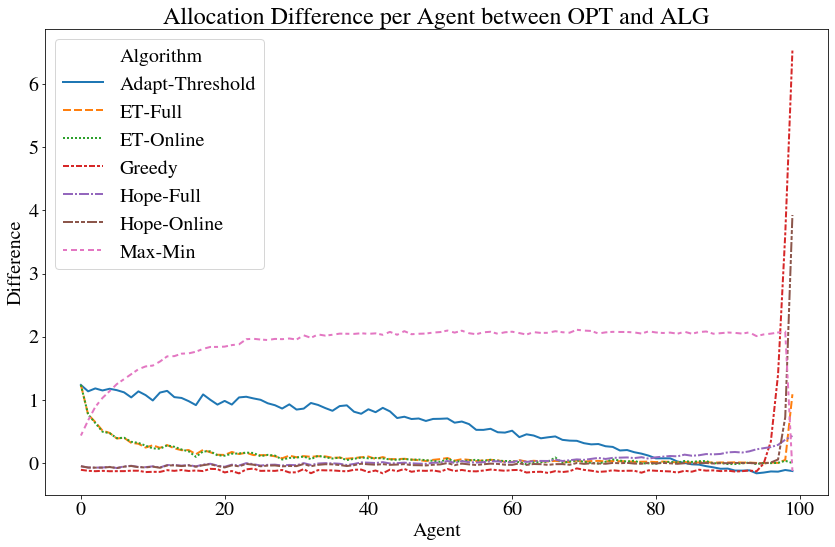

In [58]:
filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
dash_styles = ["",
               (4, 1.5),
               (1, 1),
               (3, 1, 1.5, 1),
               (5, 1, 1, 1),
               (5, 1, 2, 1, 2, 1),
               (2, 2, 3, 1.5),
               (1, 2.5, 3, 1.2)]


plt.figure(figsize=(12,8))
line = ['-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashdot']
plt.title('Maximum Difference Between OPT and ALG Allocations')

sns.lineplot(x='Agent', y='value', hue='Algorithm', data=data_to_graph, style = 'Algorithm', dashes = dash_styles, ci = None)
plt.title('Allocation Difference per Agent between OPT and ALG')
plt.ylabel('Difference')
plt.xlabel('Agent')
plt.savefig('allocation.pdf')